## 1) Importing libraries

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import tf2onnx
import onnx

## 2) Reading data

In [2]:
train = tf.keras.utils.image_dataset_from_directory(
    directory = "./chest_xray/train/",
    labels = "inferred",
    label_mode = "int",
    color_mode = "grayscale",
    batch_size = 32,
    image_size = (200, 200),
    shuffle=True
)

test = tf.keras.utils.image_dataset_from_directory(
    directory = "./chest_xray/test/",
    labels = "inferred",
    label_mode = "int",
    color_mode = "grayscale",
    batch_size = 32,
    image_size = (200, 200),
    shuffle=True
)

Found 7315 files belonging to 2 classes.
Found 620 files belonging to 2 classes.


## 3) Creating model

### 3.1) Sequential

In [3]:
model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(
        shape = (200, 200, 1)
    ),
    tf.keras.layers.Rescaling(1/.255),
    tf.keras.layers.Conv2D(filters = 32, kernel_size=(2, 2), activation = "relu"),
    tf.keras.layers.AveragePooling2D(pool_size = (2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(filters = 32, kernel_size=(2, 2), activation = "relu"),
    tf.keras.layers.AveragePooling2D(pool_size = (2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(filters = 32, kernel_size=(2, 2), activation = "relu"),
    tf.keras.layers.AveragePooling2D(pool_size = (2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Conv2D(filters = 32, kernel_size=(2, 2), activation = "relu"),
    tf.keras.layers.AveragePooling2D(pool_size = (2, 2)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units = 2, activation = "softmax")
])

model.compile(
    optimizer = tf.keras.optimizers.Adam(1E-4),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = [tf.keras.metrics.SparseCategoricalAccuracy()],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 200, 200, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 199, 199, 32)   │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 99, 99, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 99, 99, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 98, 98, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 49, 49, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 48, 48, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_2             │ (None, 24, 24, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 23, 23, 32)     │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_3             │ (None, 11, 11, 32)     │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3872)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │         7,746 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,290 (79.26 KB)

 Trainable params: 20,290 (79.26 KB)

 Non-trainable params: 0 (0.00 B)

### 3.2) Training model

In [4]:
history = model.fit(
    train,
    epochs = 100,
    shuffle = True,
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor = "loss",
            min_delta = 1E-4,
            patience = 5,
            verbose = 1,
        )
    ]
)

Epoch 1/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 74s 317ms/step - loss: 6.2907 - sparse_categorical_accuracy: 0.5799
Epoch 2/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 77s 336ms/step - loss: 1.4363 - sparse_categorical_accuracy: 0.6468
Epoch 3/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 73s 318ms/step - loss: 0.8788 - sparse_categorical_accuracy: 0.6828
Epoch 4/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 73s 317ms/step - loss: 0.6553 - sparse_categorical_accuracy: 0.7275
Epoch 5/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 72s 313ms/step - loss: 0.5221 - sparse_categorical_accuracy: 0.7785
Epoch 6/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 72s 313ms/step - loss: 0.4738 - sparse_categorical_accuracy: 0.7963
Epoch 7/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 72s 315ms/step - loss: 0.4171 - sparse_categorical_accuracy: 0.8221
Epoch 8/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 74s 321ms/step - loss: 0.3815 - sparse_categorical_accuracy: 0.8437
Epoch 9/100
229/229 ━━━━━━━━━━━━━━━━━━━━ 72s 313ms/step - loss: 0.3458 - sparse_categorical_accuracy: 0.8530
Epoch 10/100
229/22

### 3.3) Evaluating training

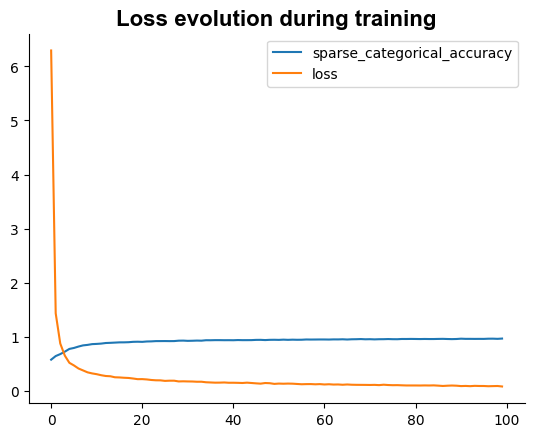

In [5]:
fig, ax = plt.subplots()

ax.plot(
    history.epoch, history.history["sparse_categorical_accuracy"], "C0", label = "sparse_categorical_accuracy"
)
ax.plot(
    history.epoch, history.history["loss"], "C1", label = "loss"
)

ax.set_title(
    label = "Loss evolution during training",
    fontsize = 16,
    fontfamily = "arial",
    fontweight = "bold",
)

ax.spines[["top", "right"]].set_visible(False)

plt.legend()
plt.show()

## 4) Saving the model

In [18]:
model.export("./models/model.onnx", format="onnx")

Saved artifact at './models/model.onnx'.
